In [16]:
from dataclasses import dataclass
from typing import Sequence, Optional

@dataclass(frozen=True)
class SDResult:
    sd_score: float          # SD_m(P) in [0, 1]

    sd_percent: float        # SD_m(P) in percent [0, 100]
    drift_point_k: Optional[int]
    sd_pk: Optional[float]   # SD_m(P, k*) before multiplying by 1/2
    sd_size: Optional[float] = None  # Deprecated


def sd_m_pk(s: Sequence[int | float], m: int, k: int) -> float:
    N = len(s)

    if (N - k < m) or (k < m) or (N < 2 * m):
        return 0.0
    if k == 0 or k == N:
        return 0.0

    left = sum(s[:k]) / k
    right = sum(1.0 - si for si in s[k:]) / (N - k)
    return left + right


def sd_score(s: Sequence[int | float], m: int) -> SDResult:
    N = len(s)

    if N == 0 or N < 2 * m:
        return SDResult(0.0, 0.0, None, None)

    best_val = 0.0
    best_k = None

    for k in range(N + 1):
        val = sd_m_pk(s, m, k)
        if val > best_val:
            best_val = val
            best_k = k

    sd_value = 0.5 * best_val          # Eq. (21)
    sd_percent = 100.0 * sd_value      # percentage
    sd_size = len(s)

    return SDResult(sd_value, sd_percent, best_k, best_val, sd_size)



In [17]:
import os
import json
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score
import numpy as np
import pandas as pd

def read_json(path):
    with open(path, 'r', encoding="utf-8") as f:
        data = json.load(f)
    return data

def write_json(data, path):
    if not os.path.exists(os.path.dirname(path)):
        os.makedirs(os.path.dirname(path))
    with open(path, 'w', encoding="utf-8") as f:
        json.dump(data, f, indent=4, ensure_ascii=False)
        

In [18]:
def normalize_predictions(predictions_path, truths_path):
    predictions = read_json(predictions_path)
    truths = read_json(truths_path)
    predictions = [predictions[i] for i in range(len(truths))]
    normalized = []
    for i in range(len(truths)):
        if predictions[i]['predict'].strip().lower() == truths[i]['relation'].strip().lower():
            normalized.append(1)
        else:
            normalized.append(0)
    return normalized

SDResult(sd_score=0.5070895522388059, sd_percent=50.708955223880594, drift_point_k=60, sd_pk=1.0141791044776118, sd_size=1400)
SDResult(sd_score=0.5178716490658002, sd_percent=51.78716490658002, drift_point_k=169, sd_pk=1.0357432981316004, sd_size=1400)
SDResult(sd_score=0.5182835820895523, sd_percent=51.82835820895523, drift_point_k=60, sd_pk=1.0365671641791045, sd_size=1400)
SDResult(sd_score=0.5268115942028986, sd_percent=52.68115942028986, drift_point_k=1380, sd_pk=1.0536231884057972, sd_size=1400)
SDResult(sd_score=0.5223880597014925, sd_percent=52.23880597014925, drift_point_k=60, sd_pk=1.044776119402985, sd_size=1400)
SDResult(sd_score=0.5182835820895523, sd_percent=51.82835820895523, drift_point_k=60, sd_pk=1.0365671641791045, sd_size=1400)
SDResult(sd_score=0.5284321689683185, sd_percent=52.84321689683185, drift_point_k=169, sd_pk=1.056864337936637, sd_size=1400)
SDResult(sd_score=0.5297101449275362, sd_percent=52.97101449275362, drift_point_k=1380, sd_pk=1.0594202898550724, s

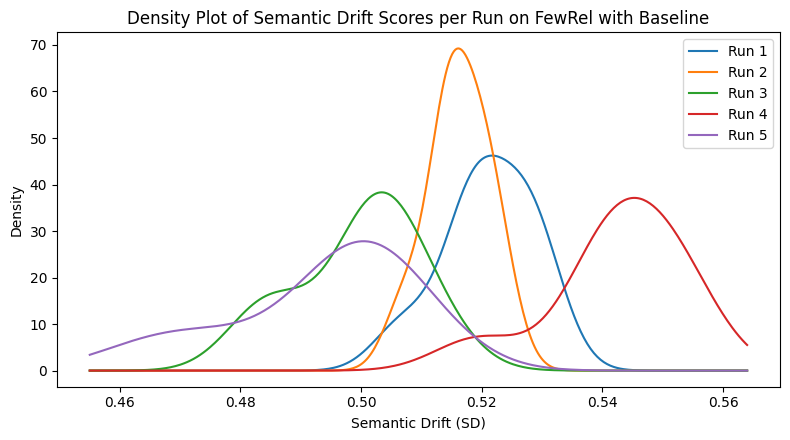

In [83]:
results = []
model = 'baseline'
for run_id in range(1, 6):
    values = []
    for task_id in range(1, 9):
        predictions_path = f'/Users/sefika/phd_projects/llm-catastrophic-re/results_all/fewrel_corrected_results/tmlr/{model}/run{run_id}/test_pred_{task_id}.json'
        truths_path = f'/Users/sefika/phd_projects/llm-catastrophic-re/results_all/fewrel_corrected_results/fewrel/test/run{run_id}/task1/test.json'
        normalized = normalize_predictions(predictions_path, truths_path)
        s = normalized
        m = 20
        res = sd_score(s, m)
        print(res)
        values.append(res.sd_score)
    row = {'run_id': run_id,
           'mean_sd': np.mean(values),
           'std_sd': np.std(values),
           'size': len(s),
           'values': values}

    results.append(row)
results_df = pd.DataFrame(results)
results_df
results_df.to_csv(f'/Users/sefika/phd_projects/llm-catastrophic-re/src/analysis/SD_score/tacred_{model}_sd_scores.csv', index=False)
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# SD values per run (from the user)
runs = {
    1: results_df.loc[results_df['run_id'] == 1, 'values'].values[0],
    2: results_df.loc[results_df['run_id'] == 2, 'values'].values[0],
    3: results_df.loc[results_df['run_id'] == 3, 'values'].values[0],
    4: results_df.loc[results_df['run_id'] == 4, 'values'].values[0],
    5: results_df.loc[results_df['run_id'] == 5, 'values'].values[0],
}

# Prepare x-grid for KDE
all_vals = np.concatenate([np.array(v) for v in runs.values()])
x_min, x_max = all_vals.min() - 0.01, all_vals.max() + 0.01
xs = np.linspace(x_min, x_max, 400)

plt.figure(figsize=(8, 4.5))

# Plot KDE for each run
for run_id, values in runs.items():
    vals = np.array(values)
    kde = gaussian_kde(vals)
    ys = kde(xs)
    plt.plot(xs, ys, label=f"Run {run_id}")

plt.xlabel("Semantic Drift (SD)")
plt.ylabel("Density")
plt.title(f"Density Plot of Semantic Drift Scores per Run on FewRel with {str.capitalize(model)}")
plt.legend()
plt.tight_layout()
plt.savefig(f'/Users/sefika/phd_projects/llm-catastrophic-re/src/analysis/SD_score/figure_fewrel/fewrel_{model}_sd_density_plot.png')
plt.show()


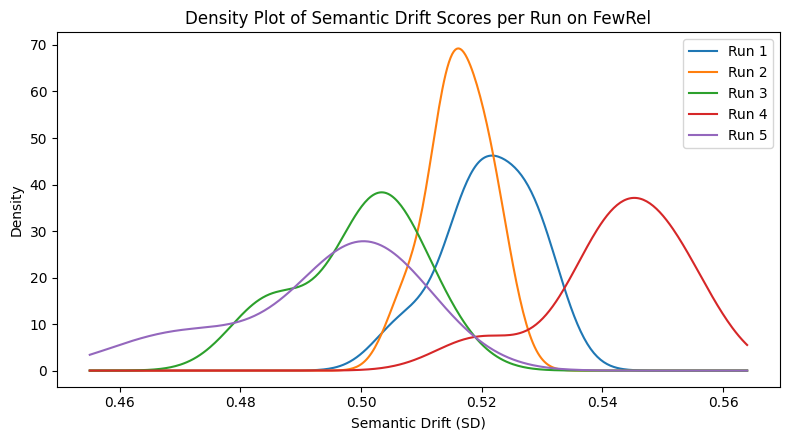

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# SD values per run (from the user)
runs = {
    1: [0.5070895522388059, 0.5178716490658002, 0.5182835820895523, 0.5268115942028986,
        0.5223880597014925, 0.5182835820895523, 0.5284321689683185, 0.5297101449275362],
    2: [0.5072575209561511, 0.5196832623041159, 0.5234802507213212, 0.5202183993856346,
        0.5143198145948662, 0.5168714681101372, 0.513734918481533, 0.5142152258782668],
    3: [0.5124716553287982, 0.48355146365650903, 0.48616535461991456, 0.4984166776619607,
        0.5067621058187096, 0.5024079693891015, 0.5034965034965035, 0.5024079693891015],
    4: [0.5194963444354184, 0.5415082956259427, 0.5447427293064877, 0.5483991064780342,
        0.5416976917349218, 0.5539587778108388, 0.5378681509711497, 0.5524852438645542],
    5: [0.5000294377391816, 0.46507430694029683, 0.5059598205057261, 0.49613756563276185,
        0.49926535830479046, 0.5084773716849189, 0.4965843931573374, 0.47741598504821664],
}

# Prepare x-grid for KDE
all_vals = np.concatenate([np.array(v) for v in runs.values()])
x_min, x_max = all_vals.min() - 0.01, all_vals.max() + 0.01
xs = np.linspace(x_min, x_max, 400)

plt.figure(figsize=(8, 4.5))

# Plot KDE for each run
for run_id, values in runs.items():
    vals = np.array(values)
    kde = gaussian_kde(vals)
    ys = kde(xs)
    plt.plot(xs, ys, label=f"Run {run_id}")

plt.xlabel("Semantic Drift (SD)")
plt.ylabel("Density")
plt.title("Density Plot of Semantic Drift Scores per Run on FewRel")
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
results_df['mean_sd'][0]

57.18817562789053